In [ ]:
from zul.utilities.OCR.docling_OCR import DoclingVLMConverter

In [ ]:
pdf_path = r"code\boilerplate\tutorial\assets\ocr\K3.pdf"
GOOGLE_MODEL_IMAGE = "gemini-3-pro-image-preview"
GOOGLE_MODEL_PRO = "gemini-3-pro-preview"
GOOGLE_API_KEY="" # punya terra


In [8]:
# https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent

In [9]:
from langchain_google_genai import ChatGoogleGenerativeAI

GEMINI

In [ ]:
vlm = ChatGoogleGenerativeAI(
    # base_url="https://llmservice.air.id",
    model=GOOGLE_MODEL_IMAGE,
    api_key=GOOGLE_API_KEY
)

In [ ]:
result = vlm.invoke("Generate an image of gray tabby cat hugging an otter with an orange scarf")

2026-01-27 01:04:29,215 - INFO - AFC is enabled with max remote calls: 10.
2026-01-27 01:04:47,204 - INFO - HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-pro-image-preview:generateContent "HTTP/1.1 200 OK"


content=[{'type': 'image_url', 'image_url': {'url': ''}, 'extras': {'signature': '...'}}] additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-pro-image-preview', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019bfb7a-846d-7891-a151-5e1d7306af4b-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 15, 'output_tokens': 1347, 'total_tokens': 1362, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 135}}

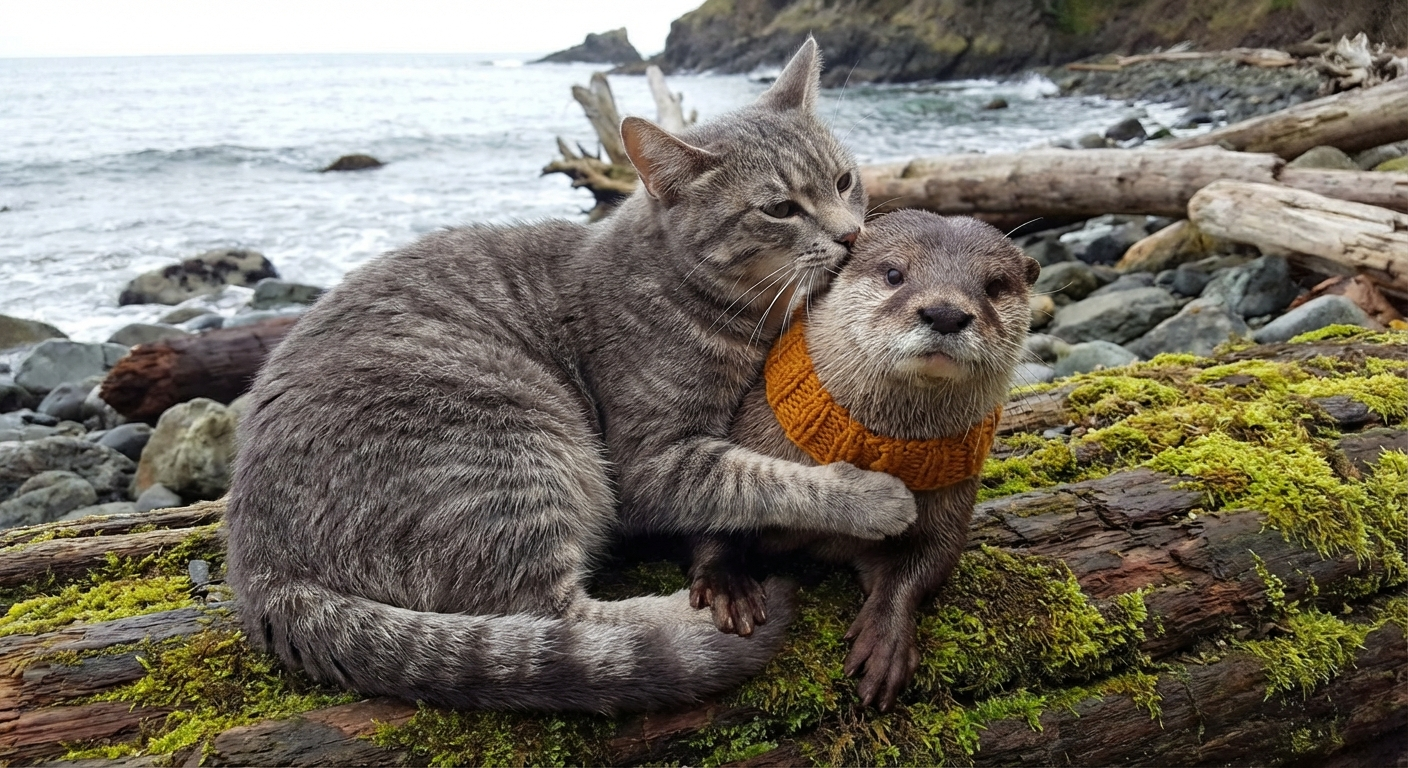

In [14]:
print(result)


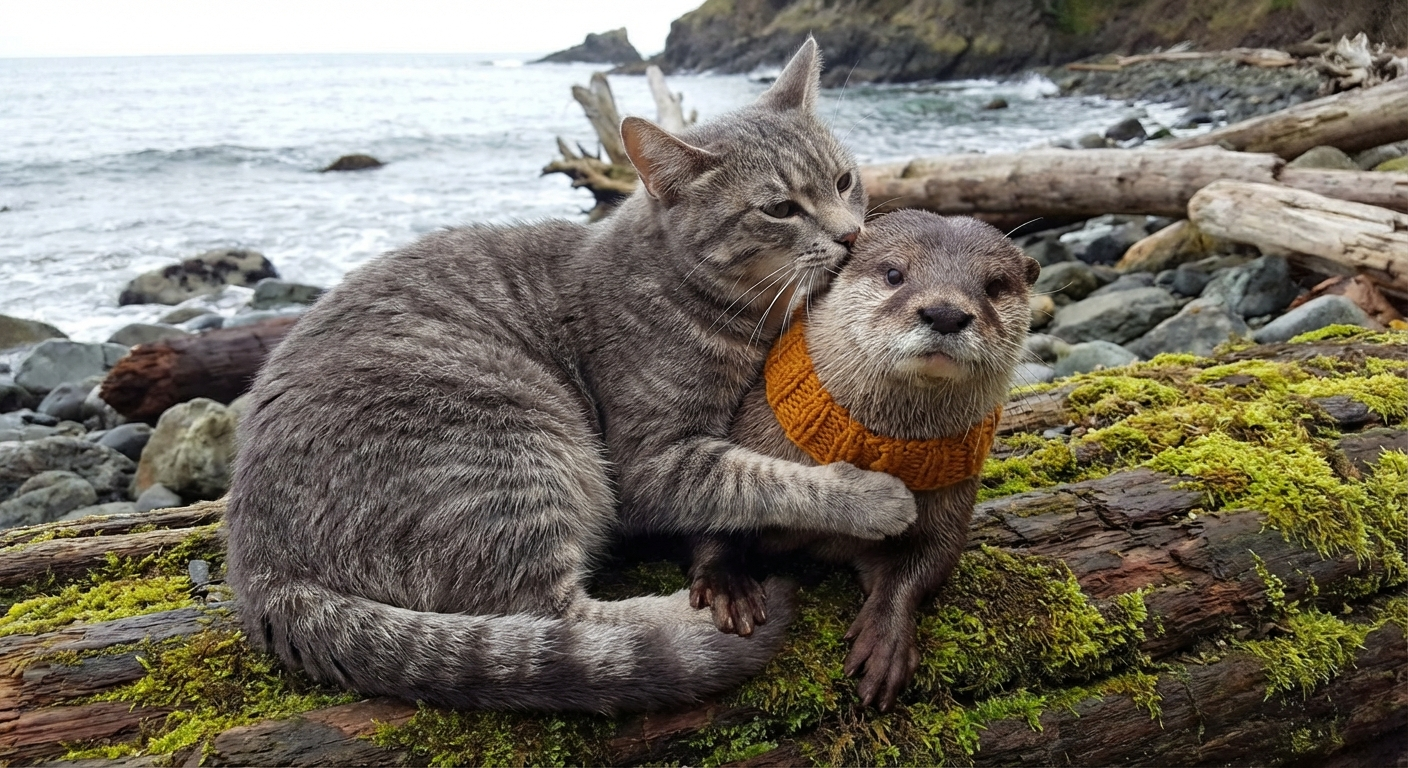

In [13]:
from IPython.display import Image, display

# Assuming 'res' is the output from your LangChain call
for part in result.content:
    if isinstance(part, dict) and part.get("type") == "image_url":
        # LangChain often uses 'image_url' with a base64 data URI
        display(Image(url=part["image_url"]["url"]))
    elif isinstance(part, dict) and "data" in part:
        # Some versions return raw bytes/base64 in a 'data' key
        display(Image(data=part["data"]))

VIDEO

In [ ]:
vlm = ChatGoogleGenerativeAI(
    # base_url="https://llmservice.air.id",
    model="veo-3.1-generate-preview",
    api_key=GOOGLE_API_KEY
)



In [38]:
import time
from google import genai
from google.genai import types

client = genai.Client(
    api_key=GOOGLE_API_KEY
)

prompt = """Drone shot following a classic red convertible driven by a man along a winding coastal road at sunset, waves crashing against the rocks below.
The convertible accelerates fast and the engine roars loudly."""

operation = client.models.generate_videos(
    model="veo-3.1-generate-preview",
    prompt=prompt,
)

# Poll the operation status until the video is ready.
while not operation.done:
    print("Waiting for video generation to complete...")
    time.sleep(10)
    operation = client.operations.get(operation)

# Download the generated video.
generated_video = operation.response.generated_videos[0]
client.files.download(file=generated_video.video)
generated_video.video.save("realism_example.mp4")
print("Generated video saved to realism_example.mp4")

2026-01-27 01:36:11,670 - INFO - HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/veo-3.1-generate-preview:predictLongRunning "HTTP/1.1 200 OK"


Waiting for video generation to complete...


2026-01-27 01:36:22,432 - INFO - HTTP Request: GET https://generativelanguage.googleapis.com/v1beta/models/veo-3.1-generate-preview/operations/99uyydsmg7g1 "HTTP/1.1 200 OK"


Waiting for video generation to complete...


2026-01-27 01:36:33,184 - INFO - HTTP Request: GET https://generativelanguage.googleapis.com/v1beta/models/veo-3.1-generate-preview/operations/99uyydsmg7g1 "HTTP/1.1 200 OK"


...

Waiting for video generation to complete...


2026-01-27 01:37:15,495 - INFO - HTTP Request: GET https://generativelanguage.googleapis.com/v1beta/models/veo-3.1-generate-preview/operations/99uyydsmg7g1 "HTTP/1.1 200 OK"


Waiting for video generation to complete...


2026-01-27 01:37:25,884 - INFO - HTTP Request: GET https://generativelanguage.googleapis.com/v1beta/models/veo-3.1-generate-preview/operations/99uyydsmg7g1 "HTTP/1.1 200 OK"
2026-01-27 01:37:25,944 - INFO - HTTP Request: GET https://generativelanguage.googleapis.com/v1beta/files/ijp7149nyf3w:download?alt=media "HTTP/1.1 302 Found"
2026-01-27 01:37:26,503 - INFO - HTTP Request: GET https://generativelanguage.googleapis.com/download/v1beta/files/ijp7149nyf3w:download?alt=media "HTTP/1.1 200 OK"


Generated video saved to realism_example.mp4


CHAT

In [24]:
vlm = ChatGoogleGenerativeAI(
    # base_url="https://llmservice.air.id",
    model=GOOGLE_MODEL_PRO,
    api_key=GOOGLE_API_KEY,
    thinking_level="low", 
)

result = vlm.invoke("what are you")
result

2026-01-27 01:16:25,528 - INFO - AFC is enabled with max remote calls: 10.
2026-01-27 01:16:32,644 - INFO - HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-pro-preview:generateContent "HTTP/1.1 200 OK"


AIMessage(content=[{'type': 'text', 'text': 'I am a large language model, trained by Google.\n\nTo break that down a bit:\n\n*   **Who am I?** My name is **Gemini**.\n*   **What do I do?** I can help with a wide variety of tasks, like writing code, drafting emails, answering questions, translating languages, brainstorming ideas, and much more.\n*   **How do I work?** I have been trained on a massive amount of text and code, which allows me to understand and generate human-like language in response to your prompts.\n\nIs there something specific you’d like to do or talk about?', 'extras': {'signature': 'EuIDCt8DAXLI2nwrrLx70GAH4mX3Cefaq/1zHfdky6FV4sTjgz2xLUgACcNfQlerBVaqetJaxXpXj8fKGRwB+ClmIurv0fMiSL1cRXiBEXmT7eNU1jf2E+6e59kh7GOLkczRLZoMzfn8uZHFZiVELiPtzmH3W6D3cSsmL1XrrPJEW7qvWelouxEnZ0Z83+fjeh5K7sHFkGucoNep8mUYn7ru9V044VLBwwYY5XzGrZ0l8+RRs+3SMbS9cLX9C2tXYChSbBR+HbQ8hZC1wAlhXLzH9KDZhoe27TtD9Y8s4C85vGaUCQp9K9/WYZ/LGLanUt1nkZDWqbNolFU+SGp9qUGfW2aU+YQZgUMXLBo+jtom68lfkV3n7+ZOJV4jFt1hjleFO5

In [16]:
print(result)

content=[{'type': 'text', 'text': 'I am **Gemini**, a large language model trained by Google.\n\nHere is a breakdown of what that means:\n\n*   **I am Artificial Intelligence:** I am software designed to process information and communicate in a way that mimics human understanding.\n*   **I am a Large Language Model (LLM):** You can think of me as a very sophisticated pattern-matching engine. I have been trained on a massive dataset of text and code. This training allows me to understand the relationships between words and ideas, which helps me interpret your prompts and generate relevant, coherent responses.\n*   **My Purpose:** I am designed to be a helpful and collaborative tool. I can assist with a wide variety of tasks, such as answering questions, writing creative content, translating languages, summarizing text, and writing computer code.\n\nUltimately, I am a machine. I do not have thoughts, feelings, consciousness, or personal experiences like a human does. My responses are bas

OCR

In [40]:
HOSTNAME_GEMINI = f"https://generativelanguage.googleapis.com/v1beta/models/{GOOGLE_MODEL_IMAGE}:generateContent?key={GOOGLE_API_KEY}"
converter = DoclingVLMConverter(
    model=GOOGLE_MODEL_IMAGE, 
    hostname_and_port=HOSTNAME_GEMINI,
    api_key=GOOGLE_API_KEY,  # Google AI Studio / Vertex AI key
    prompt="Convert this page to markdown.",
    response_format="markdown",
    enable_picture_description=True,  # Untuk flowchart images
    temperature=0.0
)

result = converter.convert(pdf_path)
markdown = result.document.export_to_markdown()

2026-01-27 01:42:22,229 - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]
2026-01-27 01:42:22,241 - INFO - Going to convert document batch...
2026-01-27 01:42:22,243 - INFO - Initializing pipeline for VlmPipeline with options hash b52b5234d3f6853a0201e5c7d4f5859c
2026-01-27 01:42:22,244 - INFO - Processing document K3.pdf
2026-01-27 01:42:26,605 - ERROR - Error calling the API. Response was {
  "error": {
    "code": 401,
    "message": "Request had invalid authentication credentials. Expected OAuth 2 access token, login cookie or other valid authentication credential. See https://developers.google.com/identity/sign-in/web/devconsole-project.",
    "status": "UNAUTHENTICATED",
    "details": [
      {
        "@type": "type.googleapis.com/google.rpc.ErrorInfo",
        "reason": "ACCESS_TOKEN_TYPE_UNSUPPORTED",
        "metadata": {
          "method": "google.ai.generativelanguage.v1beta.GenerativeService.GenerateContent",
          "service": "generativelanguage.googleapis.com"
 

KeyboardInterrupt: 